# vGRU forecasting of renewable energy grid production
## - Lookback = 12 timesteps = 2hr
## - lr = 0.001, hidden_size = 35, num_epochs = 50, batch_size = 512

## Model Architecture
### 1 Linear input layer
### 1 GRU
### 1 Linear layer
### 1 vLinear layer to output

### Import packages, set seed, define model

In [4]:
from psml.data_handler import *
from psml.trainer import *
from psml.uncertainty import *
from psml.linear_variational import *
import torch
import torch.nn as nn
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, RobustScaler
from torch.utils.data import TensorDataset, DataLoader
import random

def set_random_seed(seed_value=42):
    # Python random seed
    random.seed(seed_value)
    
    # Numpy random seed
    np.random.seed(seed_value)
    
    # PyTorch seed
    torch.manual_seed(seed_value)
    
    # If using CUDA (GPU)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)  # if using multi-GPU
        torch.backends.cudnn.deterministic = True  # For reproducibility
        torch.backends.cudnn.benchmark = False  # Disable auto-optimization for determinism

set_random_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

class GRUReparameterizationModel(nn.Module):
    def __init__(
        self,
        in_features,
        hidden_size,
        out_features,
        num_layers,
        prior_mean=0,
        prior_variance=1.0,
        posterior_rho_init=-3.0,
        bias=True
    ):
        super().__init__()

        # 1) Deterministic input projection
        self.fc1 = nn.Linear(in_features, hidden_size, bias=bias)

        # 2) Deterministic multi-layer GRU
        self.gru = nn.GRU(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bias=bias
        )

        # 3) Deterministic penultimate layer
        self.fc2 = nn.Linear(hidden_size, hidden_size, bias=bias)

        # 4) **Only this** is variational
        self.fc3 = LinearReparameterization(
            in_features=hidden_size,
            out_features=out_features,
            prior_mean=prior_mean,
            prior_variance=prior_variance,
            posterior_rho_init=posterior_rho_init,
            bias=bias
        )

    def forward(self, x, hidden_states=None):
        # x: (batch, seq_len, in_features)

        # 1) Deterministic linear + ReLU
        x = self.fc1(x)                 # → (batch, seq_len, hidden_size)
        x = F.relu(x)

        # 2) Deterministic GRU
        # hidden_states (if provided) must be (num_layers, batch, hidden_size)
        hidden_seq, h_n = self.gru(x, hidden_states)
        # h_n: (num_layers, batch, hidden_size)
        last_hidden = h_n[-1]           # → (batch, hidden_size)

        # 3) Deterministic linear + ReLU
        last_hidden = self.fc2(last_hidden)
        last_hidden = F.relu(last_hidden)

        # 4) Variational output layer
        output, kl = self.fc3(last_hidden)

        return output, kl

cuda


In [6]:
#-----------------------------------------------LOAD DATA---------------------------------------------------------#
df = pd.read_csv('../../dataset/PSML.csv', parse_dates=['time'])
print(df.shape)
df.set_index('time', inplace=True)
df1 = df.fillna(method='ffill').fillna(method='bfill')

(1573923, 12)


C:\Users\Logan\AppData\Local\Temp\ipykernel_36808\3843613944.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df1 = df.fillna(method='ffill').fillna(method='bfill')


In [8]:
#---------------------------------SPLIT, SCALE, AND CONVERT TO NP ARRAYS---------------------------------------#

# Use the function with a list of target columns
X, y = feature_label_split(df1, targets=['solar_power', 'wind_power'], drop_cols=['load_power'])  # Predicting renewable energy production, not overall grid demand

# Split data
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(X, y, train_fraction=0.20, validation_fraction=0.20, test_fraction=0.60)

# Scaling
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_arr = scaler_X.fit_transform(X_train)
X_val_arr = scaler_X.transform(X_val)       # All as numpy.nd arrays
X_test_arr = scaler_X.transform(X_test)

y_train_arr = scaler_y.fit_transform(y_train)
y_val_arr = scaler_y.transform(y_val)
y_test_arr = scaler_y.transform(y_test)

#---------------------------------DEFINE LOOKBACK AND FORMAT DATA------------------------------------------#

# Define the sequence length
seq_length = 12

# Convert training, validation, and test sets into sequences
train_features_seq, train_targets_seq = create_sequences(torch.Tensor(X_train_arr), torch.Tensor(y_train_arr), seq_length)
val_features_seq, val_targets_seq = create_sequences(torch.Tensor(X_val_arr), torch.Tensor(y_val_arr), seq_length)
test_features_seq, test_targets_seq = create_sequences(torch.Tensor(X_test_arr), torch.Tensor(y_test_arr), seq_length)

# Check the new shapes of the data
print(f"Train features shape: {train_features_seq.shape}")
print(f"Train targets shape: {train_targets_seq.shape}")
print(f"Test features shape: {test_features_seq.shape}")
print(f"Test targets shape: {test_targets_seq.shape}")

#--------------------------STORE AS TENSORDATASET AND CREATE DATALOADERS-----------------------------#

# Create TensorDatasets
train = TensorDataset(train_features_seq, train_targets_seq)
val = TensorDataset(val_features_seq, val_targets_seq)
test = TensorDataset(test_features_seq, test_targets_seq)

# Create DataLoaders
batch_size = 512
train_loader = DataLoader(train, batch_size=batch_size, shuffle=False, drop_last=True)
val_loader = DataLoader(val, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False, drop_last=True)

# Investigating the shape of data in train_loader
for batch_idx, (inputs, targets) in enumerate(train_loader):
    print(f"Batch {batch_idx+1}:")
    print(f"  Input shape: {inputs.shape}")
    print(f"  Target shape: {targets.shape}")
    
    # Break after inspecting the first batch
    break

Train features shape: torch.Size([314772, 12, 8])
Train targets shape: torch.Size([314772, 2])
Test features shape: torch.Size([944342, 12, 8])
Test targets shape: torch.Size([944342, 2])
Batch 1:
  Input shape: torch.Size([512, 12, 8])
  Target shape: torch.Size([512, 2])


### Instantiate and train vGRU model

In [10]:
# Hyperparameters from GridSearch
num_layers = 1
lr = 0.001
hidden_size = 35
num_epochs = 50

# Initialize model with current hyperparameters
model = GRUReparameterizationModel(
    in_features=8,  # Adjust based on input features
    hidden_size=hidden_size,
    out_features=2,  # Adjust based on output features
    num_layers=num_layers
)

# Initialize optimizer with learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Define loss function
reconstruction_loss_fn = torch.nn.MSELoss()  # regression task

# Timing
start = time.time()

# Train and validate the model
train_losses, val_losses = train_model(model, train_loader, val_loader, num_epochs=num_epochs, reconstruction_loss_fn=reconstruction_loss_fn, optimizer=optimizer, device=device)

end = time.time()
train_time = end - start
print(f"Training time: {train_time:.4f} seconds")

Epoch [1/50], Train Loss: 0.0132, Val Loss: 0.0111, KL Weight: 0.0001
Epoch [2/50], Train Loss: 0.0044, Val Loss: 0.0080, KL Weight: 0.0001
Epoch [3/50], Train Loss: 0.0036, Val Loss: 0.0053, KL Weight: 0.0001
Epoch [4/50], Train Loss: 0.0026, Val Loss: 0.0079, KL Weight: 0.0001
Epoch [5/50], Train Loss: 0.0024, Val Loss: 0.0079, KL Weight: 0.0001
Epoch [6/50], Train Loss: 0.0023, Val Loss: 0.0041, KL Weight: 0.0001
Epoch [7/50], Train Loss: 0.0017, Val Loss: 0.0055, KL Weight: 0.0001
Epoch [8/50], Train Loss: 0.0017, Val Loss: 0.0052, KL Weight: 0.0001
Epoch [9/50], Train Loss: 0.0014, Val Loss: 0.0051, KL Weight: 0.0001
Epoch [10/50], Train Loss: 0.0015, Val Loss: 0.0055, KL Weight: 0.0001
Epoch [11/50], Train Loss: 0.0013, Val Loss: 0.0053, KL Weight: 0.0001
Epoch [12/50], Train Loss: 0.0013, Val Loss: 0.0056, KL Weight: 0.0001
Epoch [13/50], Train Loss: 0.0012, Val Loss: 0.0057, KL Weight: 0.0001
Epoch [14/50], Train Loss: 0.0012, Val Loss: 0.0052, KL Weight: 0.0001
Epoch [15/50], 

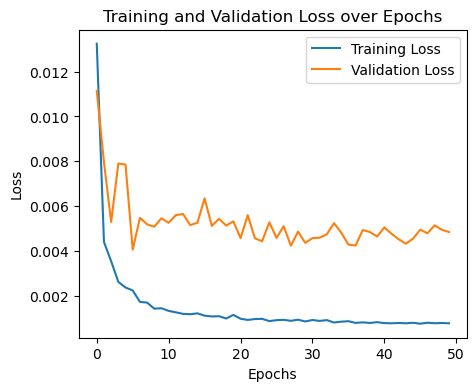

In [14]:
# Create the main plot
plt.figure(figsize=(5, 4))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss over Epochs")
plt.legend(loc='upper right')
plt.show()

# Predict on test data

In [18]:
n_samples = 50

# Timing
start = time.time()

# Predict on test data, sampling to obtain uncertainty estimation, plot for each output
mean_predictions, true_values, lower_ci, upper_ci = predict_with_uncertainty(model, test_loader, n_samples=n_samples, scaler_y=scaler_y, device=device)

end = time.time()
infer_time = end - start
print(f"Inference time: {infer_time:.4f} seconds")

Inference time: 353.6052 seconds


In [22]:
# say your stored 95% interval is [lower_ci, upper_ci] from predict_with_uncertainty
inside_95 = ((true_values >= lower_ci) & (true_values <= upper_ci)).mean(axis=0)
print("Empirical 95% coverage per output:", inside_95)

Empirical 95% coverage per output: [0.6628741 0.8947039]


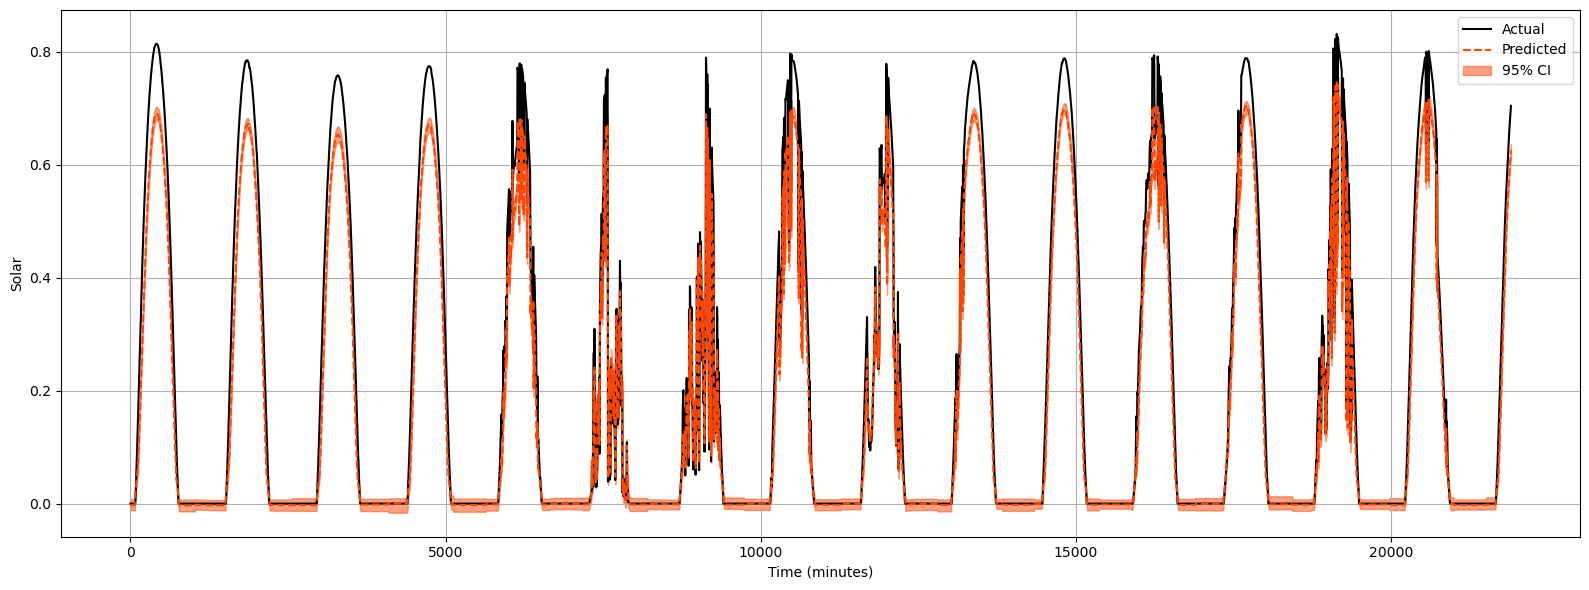

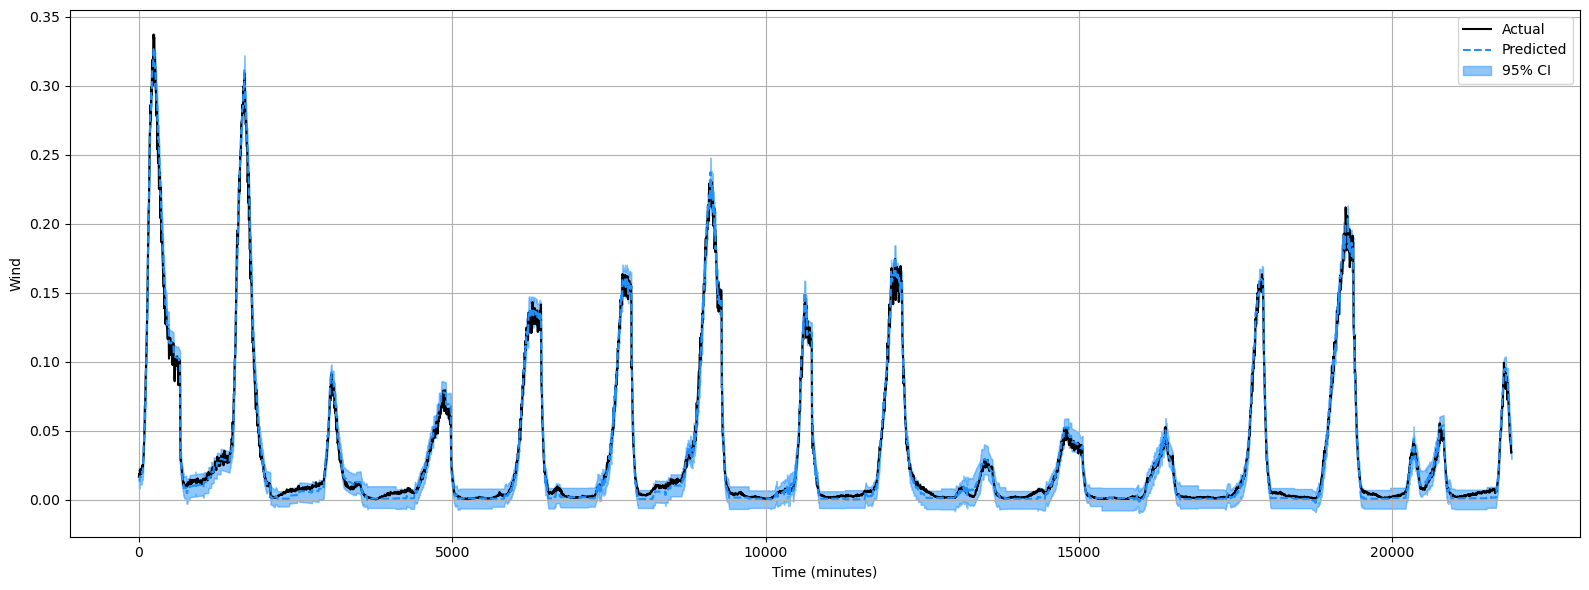

In [24]:
plot_predictions(
    mean_predictions,
    true_values,
    n_display=43800//2,
    lower=lower_ci,
    upper=upper_ci
)

# Calculate R2, MAE, RMSE

In [47]:
calculate_and_display_metrics(true_values, mean_predictions)

Output 1:
  R² score: 0.9498
  MAE score: 0.0291
  RMSE score: 0.0597

Output 2:
  R² score: 0.9943
  MAE score: 0.0035
  RMSE score: 0.0057



In [49]:
def save_arrays_to_csv(
    true_values: np.ndarray,
    mean_predictions: np.ndarray,
    lower_ci: np.ndarray,
    upper_ci: np.ndarray,
    filename: str
):
    """
    Saves true values, predicted means, and prediction intervals to a CSV.
    
    Args:
        true_values      (np.ndarray): shape (N, 2) for solar and wind true values.
        mean_predictions (np.ndarray): shape (N, 2) for solar and wind predicted means.
        lower_ci         (np.ndarray): shape (N, 2) for solar and wind lower confidence bounds.
        upper_ci         (np.ndarray): shape (N, 2) for solar and wind upper confidence bounds.
        filename         (str): path to the output CSV file.
    """
    df = pd.DataFrame({
        'True Solar':            true_values[:, 0],
        'True Wind':             true_values[:, 1],
        'Predicted Mean Solar':  mean_predictions[:, 0],
        'Predicted Mean Wind':   mean_predictions[:, 1],
        'Lower CI Solar':        lower_ci[:, 0],
        'Lower CI Wind':         lower_ci[:, 1],
        'Upper CI Solar':        upper_ci[:, 0],
        'Upper CI Wind':         upper_ci[:, 1],
    })
    df.to_csv(filename, index=False)


save_arrays_to_csv(true_values, mean_predictions, lower_ci, upper_ci, 'vGRUTest.csv')